# **Importacion del dataset**

In [6]:
import pandas as pd
# Se exporta el dataset desde google drive, ya que no era posible exportarlo direcamente de kaggle
file_path = 'https://raw.githubusercontent.com/Alanffc/Talent-Retention-Analytics/main/WA_Fn-UseC_-HR-Employee-Attrition.csv'
df = pd.read_csv(file_path)


In [7]:
display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# **Contexto y Objetivo del caso**


### **Interpretación de las Curvas ROC y Precision-Recall**

*   **Curva ROC (Receiver Operating Characteristic):** Muestra el rendimiento de un modelo de clasificación en todos los umbrales de clasificación. Se grafica la Tasa de Verdaderos Positivos (TPR) contra la Tasa de Falsos Positivos (FPR).
    *   El **Área bajo la Curva ROC (AUC-ROC)** mide la capacidad del modelo para distinguir entre clases. Un AUC de 0.5 sugiere un clasificador aleatorio, mientras que un AUC de 1.0 indica un clasificador perfecto.

*   **Curva Precision-Recall (PR):** Es particularmente útil para evaluar clasificadores en conjuntos de datos desequilibrados, como el nuestro con `Attrition`. Muestra la relación entre Precisión (cuántas predicciones positivas fueron correctas) y Recall (cuántos positivos reales fueron detectados).
    *   El **Área bajo la Curva PR (AUC-PR)** proporciona una medida más robusta del rendimiento que el AUC-ROC en problemas con desbalance de clases, ya que se centra en el rendimiento de la clase minoritaria.

### **¿De qué trata este proyecto y qué queremos lograr?**
En este notebook vamos a analizar datos de los empleados de una empresa. Nos vamos a enfocar en dos cosas que son clave para cualquier negocio: la rotación (cuando la gente renuncia) y los sueldos.

¿Por qué importa si la gente se va? (Attrition): Que los empleados se vayan a cada rato le sale caro a la empresa. No solo es perder a alguien que ya sabía hacer su trabajo, sino también gastar tiempo y plata buscando a alguien nuevo y enseñándole todo desde cero. Si entendemos por qué se van, podemos hacer algo para que se queden contentos.

¿Por qué importan los sueldos? (MonthlyIncome): El sueldo es lo que más motiva a la gente y es uno de los gastos más grandes de la empresa. Si podemos predecir cuánto debería ganar alguien, la empresa puede repartir mejor el presupuesto, pagar lo justo comparado con otros trabajos y planificar bien sus gastos.

#### Metas del análisis:
Predecir el sueldo (Regresión): Queremos calcular cuánto debería ser el MonthlyIncome de un empleado usando los demás datos que tenemos. Como el sueldo es un número que varía (no es una categoría fija), usamos un modelo de regresión.

Saber quién se va a ir (Clasificación): Queremos adivinar si un empleado va a dejar la empresa o no (Attrition). Como la respuesta es simple (Sí o No), esto es un problema de clasificación.

#### ¿Qué variables vamos a predecir?
* Para el modelo de sueldos: Nuestra meta es predecir MonthlyIncome.

* Para el modelo de renuncias: Nuestra meta es predecir Attrition.



# **Exploracion y calidad de dato**



In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [11]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\nDistribución por columna: {col}")
    print(df[col].value_counts())



Distribución por columna: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Distribución por columna: BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Distribución por columna: Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Distribución por columna: EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Distribución por columna: Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

Distribución por columna: JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Represen

In [12]:
correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
print("Matriz de correlación (primeros valores 5x5):\n")
display(correlation_matrix.head())

Matriz de correlación (primeros valores 5x5):



,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


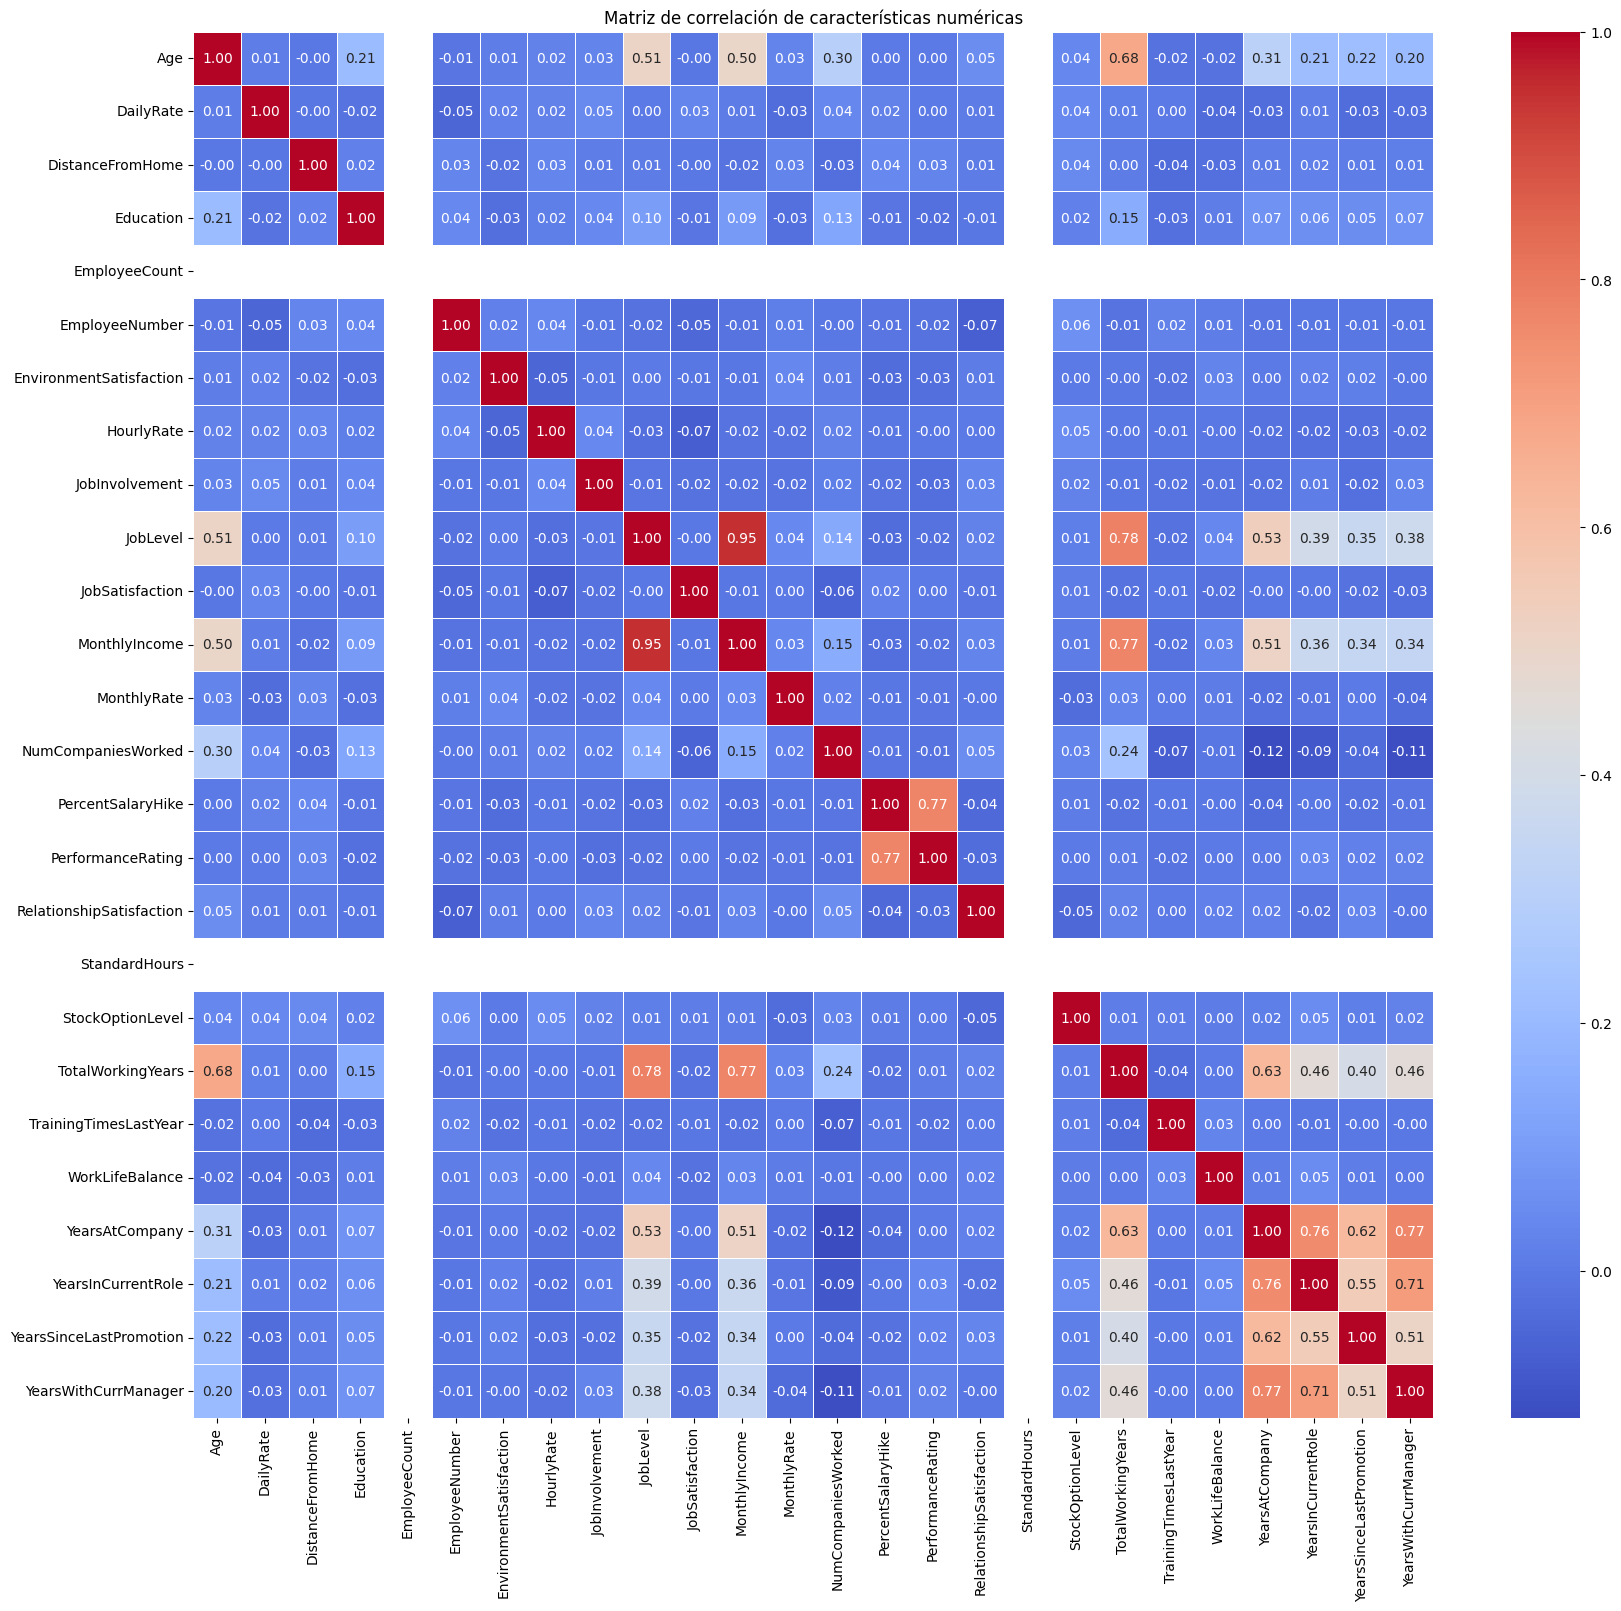

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de correlación de características numéricas')
plt.show()

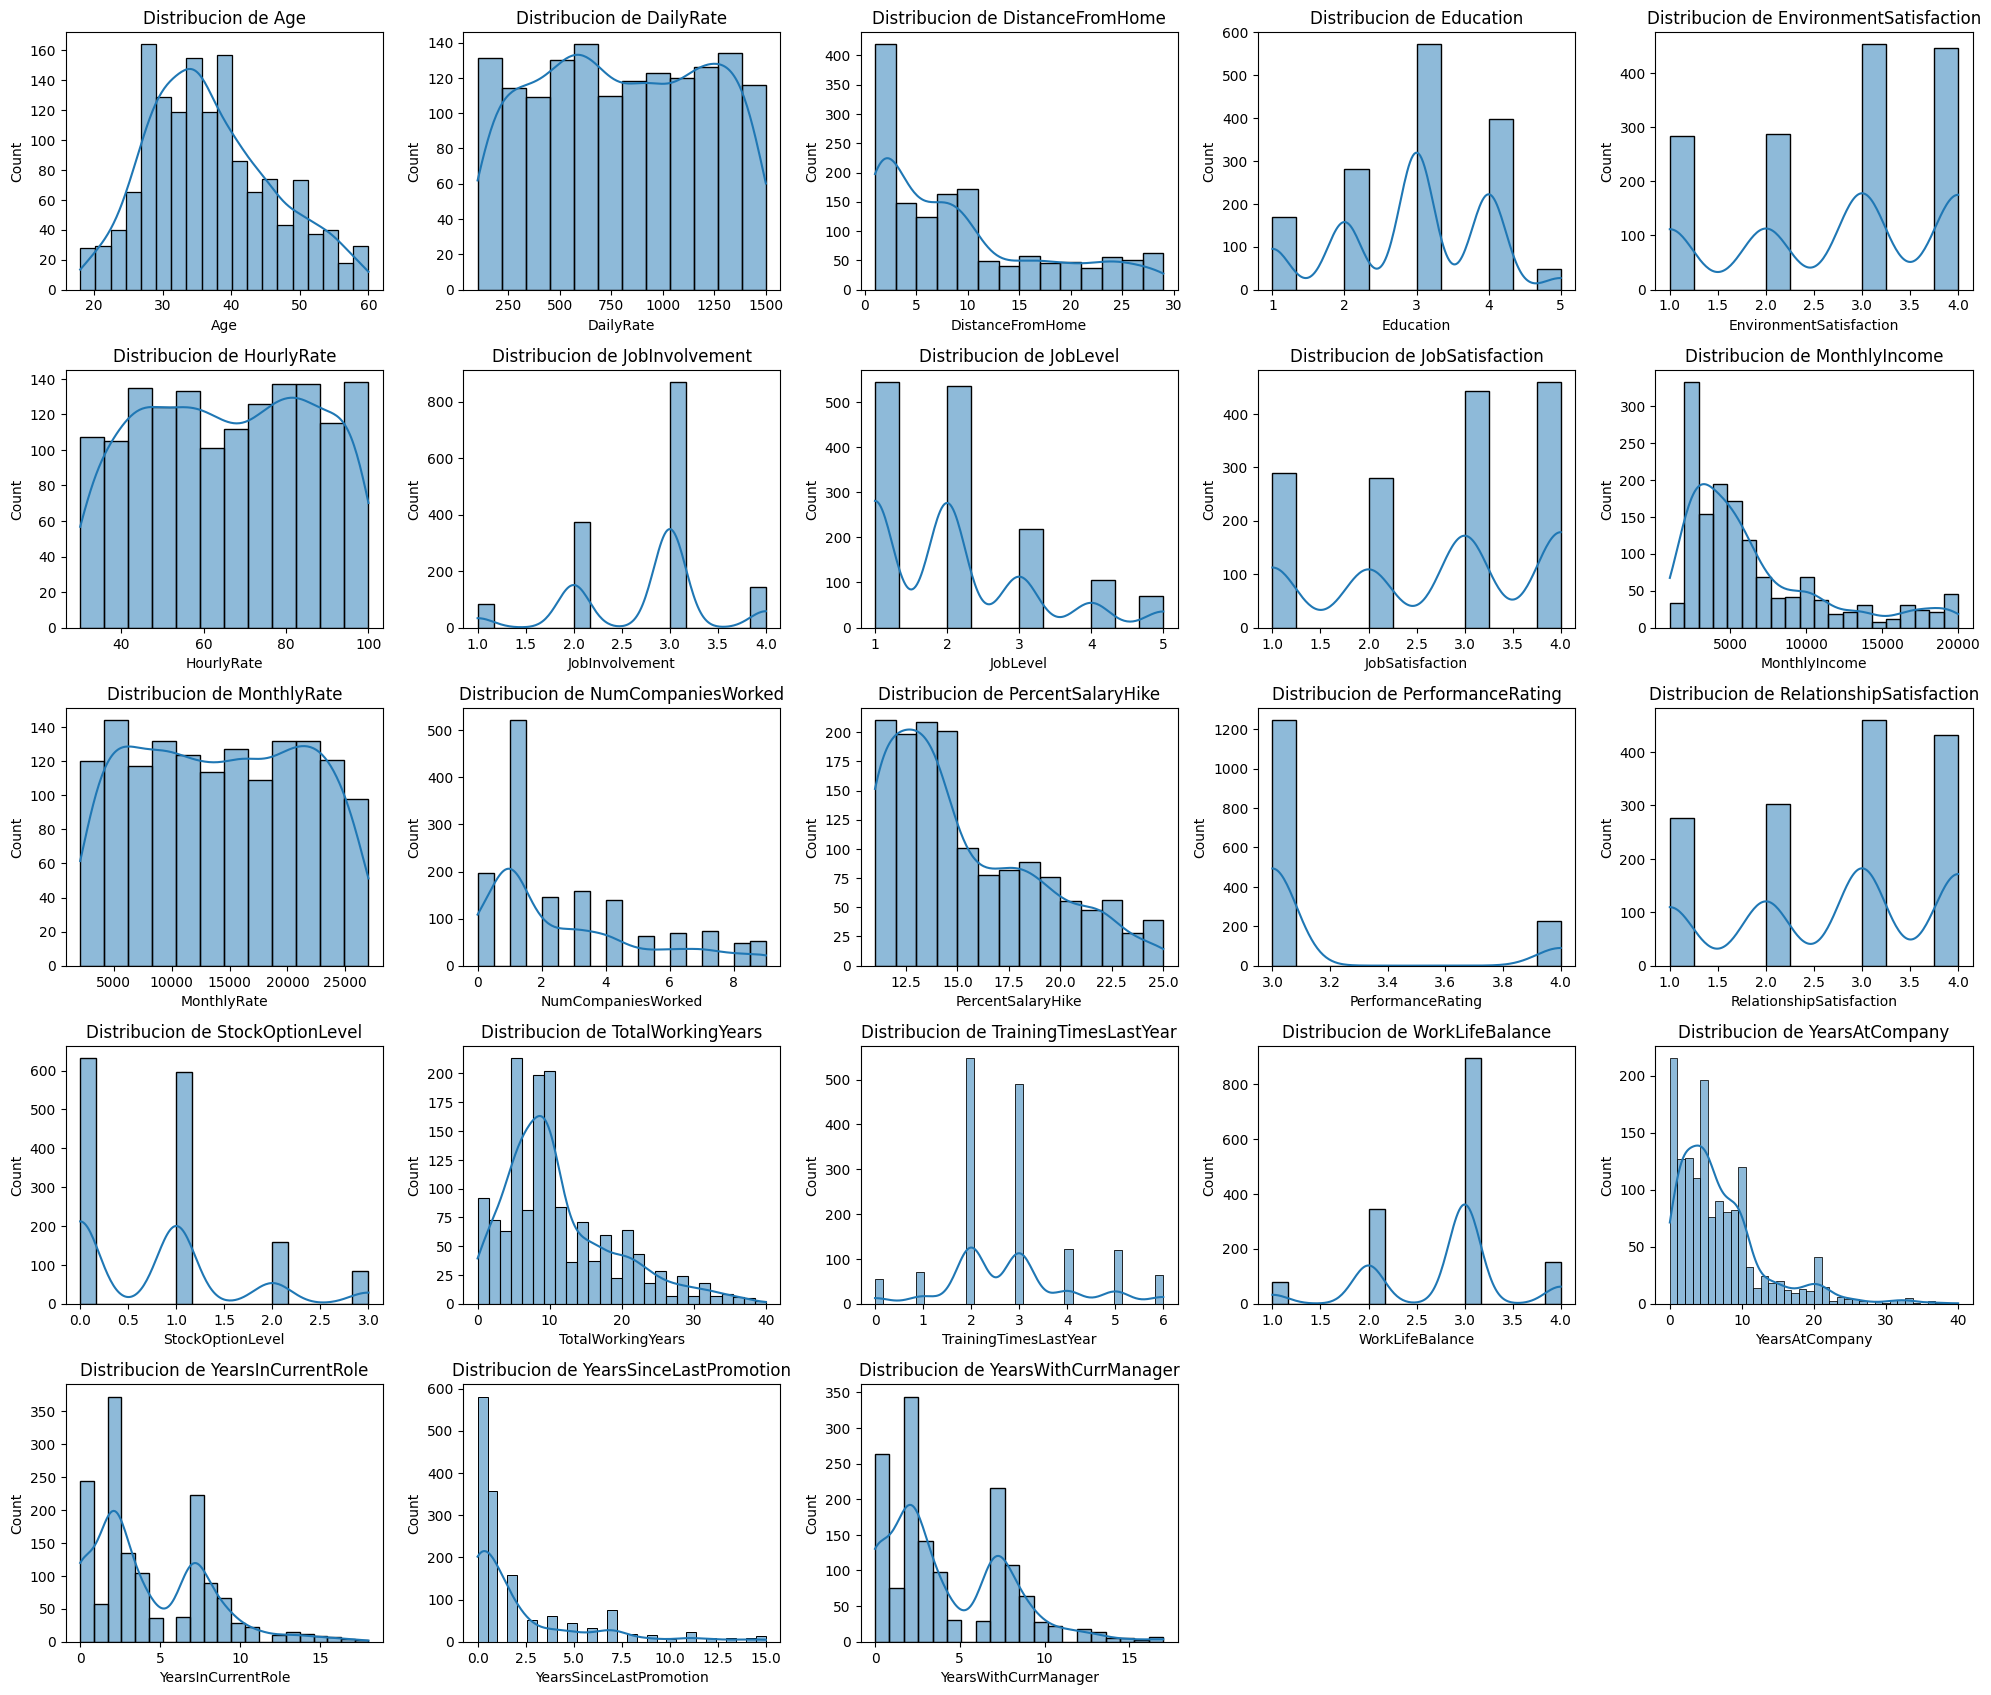

In [14]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
# Se excluye 'EmployeeCount' y 'StandardHours' porque son constantes
numerical_cols = [col for col in numerical_cols if col not in ['EmployeeCount', 'StandardHours', 'EmployeeNumber']]

plt.figure(figsize=(20, 20))
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 5, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribucion de {col}')
    plt.tight_layout()
plt.show()

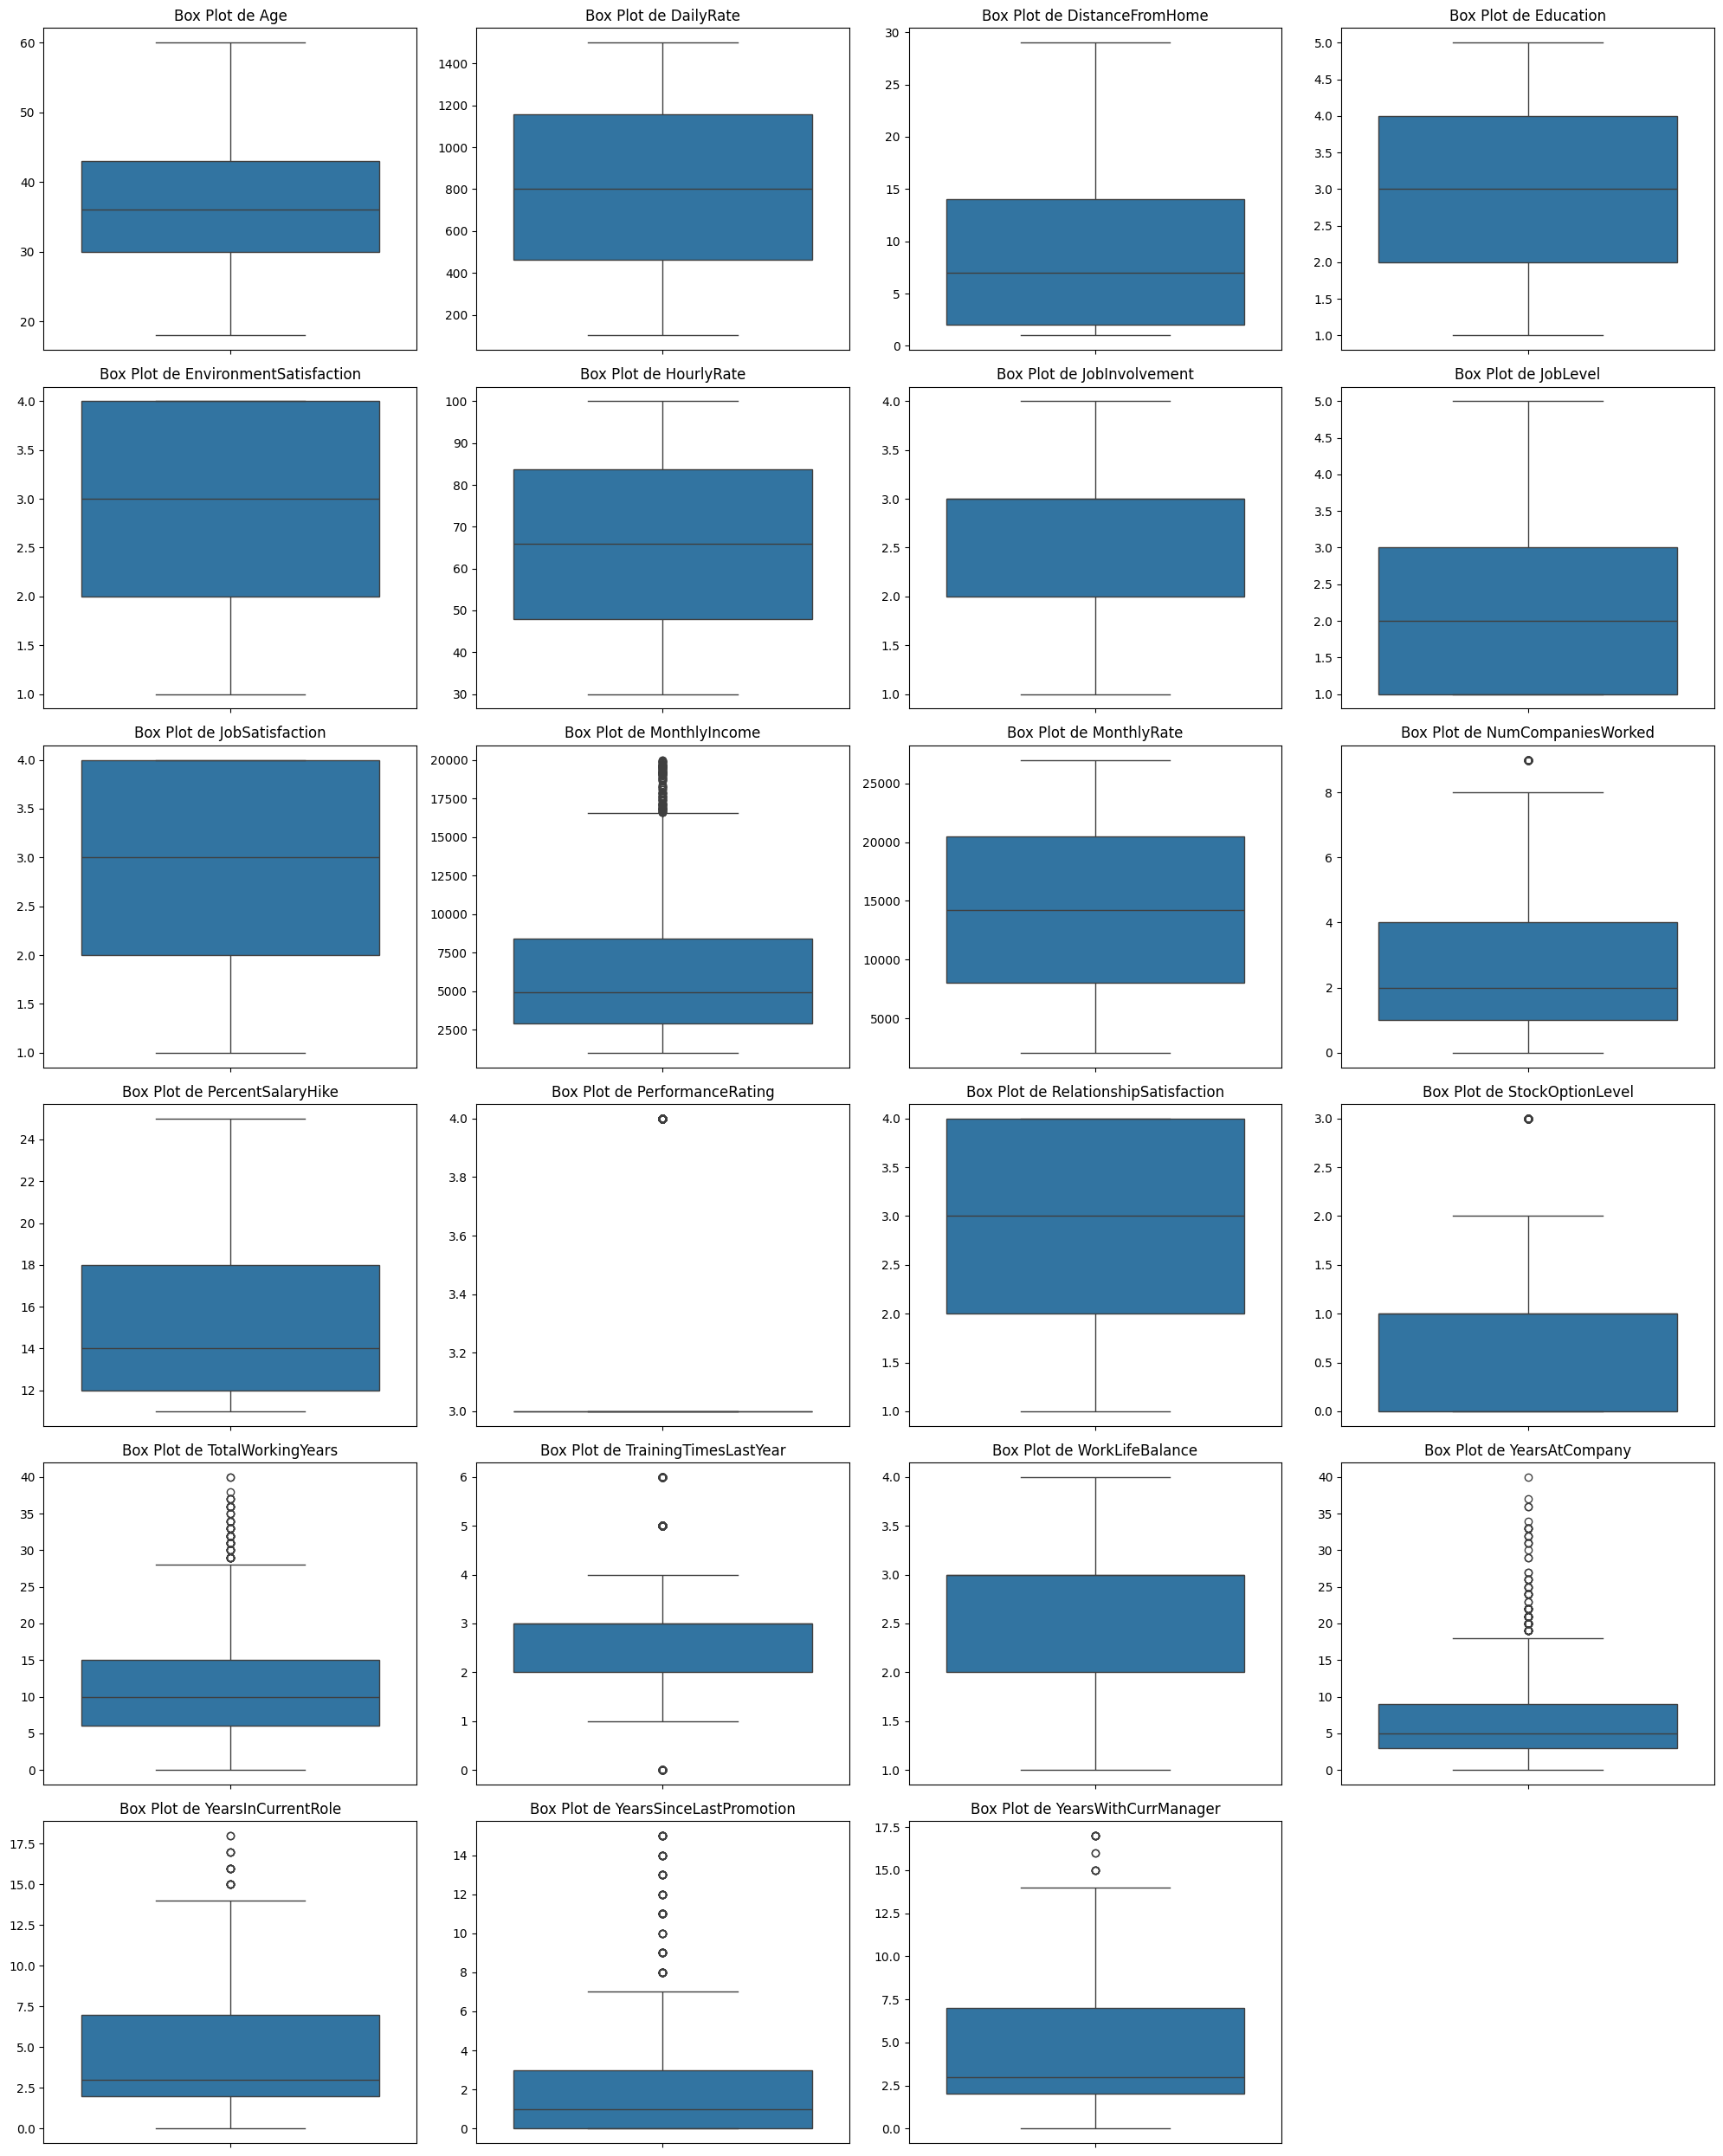

In [15]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
# Se excluye 'EmployeeCount', 'StandardHours', y 'EmployeeNumber' porque son constantes o monotonicas
numerical_cols = [col for col in numerical_cols if col not in ['EmployeeCount', 'StandardHours', 'EmployeeNumber']]

plt.figure(figsize=(20, 25))
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot de {col}')
    plt.ylabel('')
    plt.tight_layout()
plt.show()

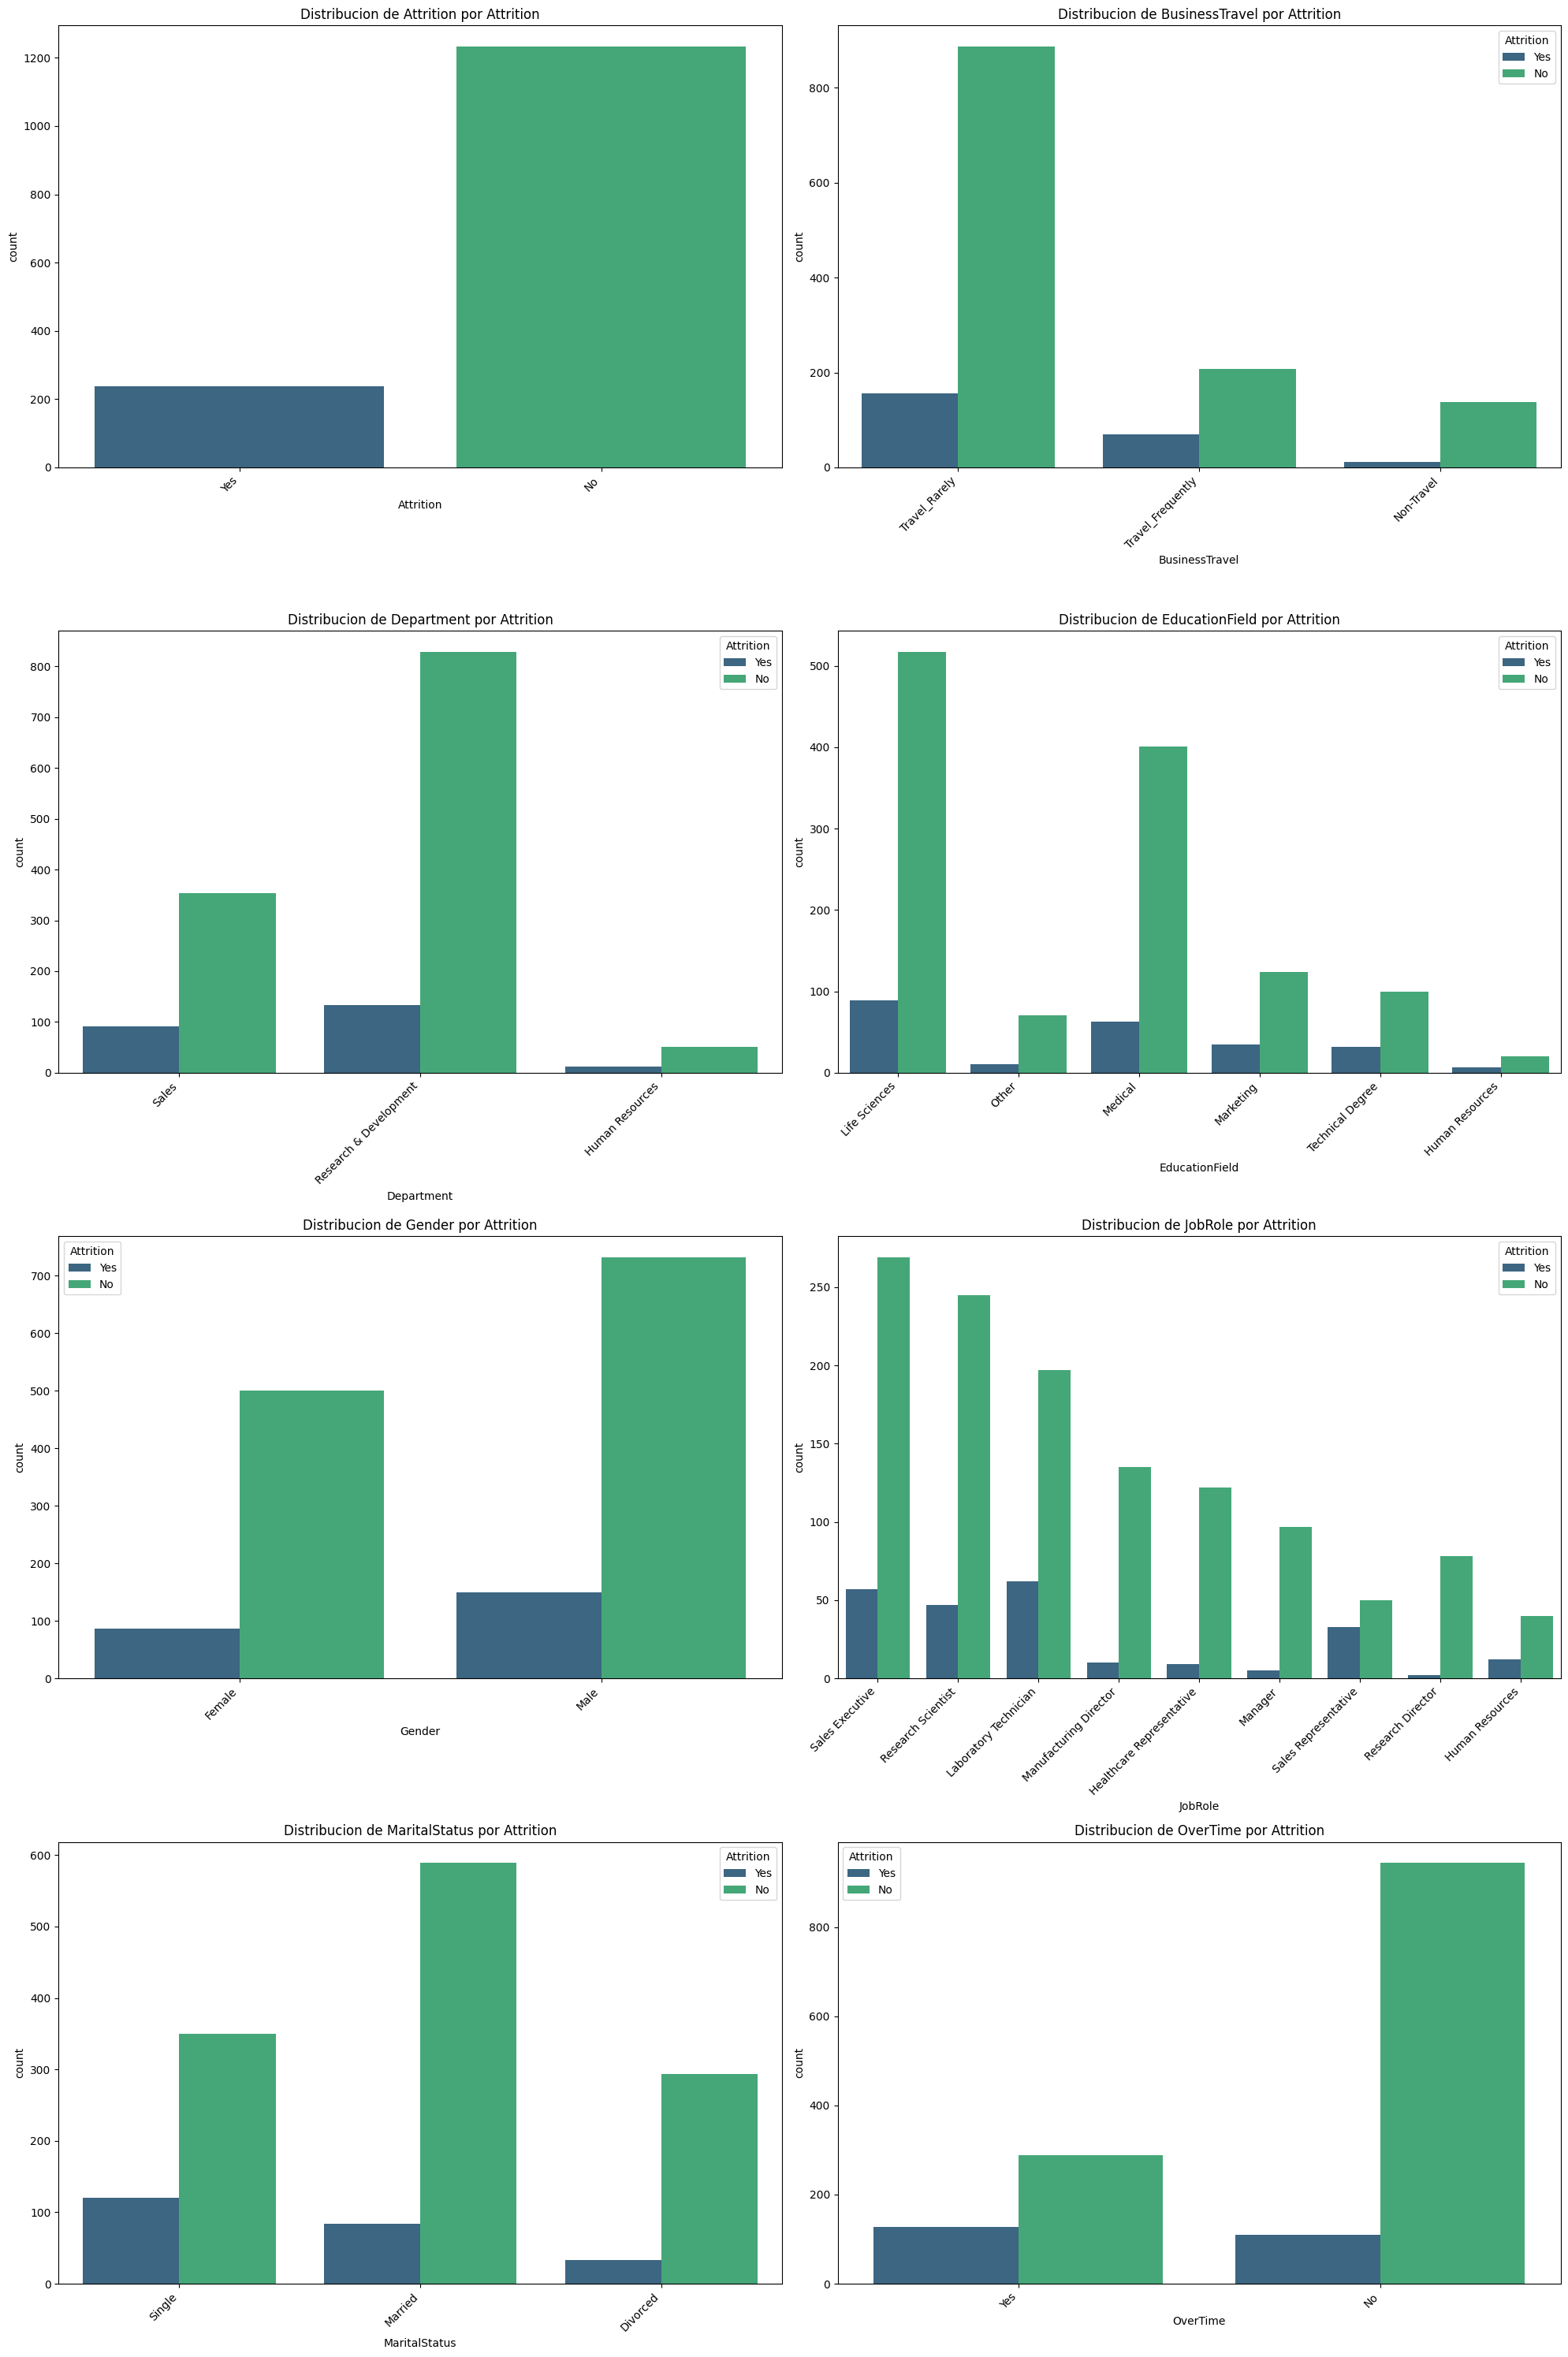

In [16]:
categorical_cols = df.select_dtypes(include='object').columns
# Se excluye 'Attrition' porque se estan ordentando el resto de features en base a este
categorical_cols = [col for col in categorical_cols if col not in ['Over18']]

plt.figure(figsize=(20, 30))
for i, col in enumerate(categorical_cols):
    plt.subplot(round(len(categorical_cols)/2), 2, i + 1)
    sns.countplot(data=df, x=col, hue='Attrition', palette='viridis')
    plt.title(f'Distribucion de {col} por Attrition')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
plt.show()

## **Análisis de Fuga de Información y Columnas Irrelevantes**

Identificar y documentar variables que podrían generar fuga de información (data leakage) y justificarlas. También se buscarán columnas constantes o con baja varianza para su posible eliminación, justificando la decisión con evidencia (por ejemplo, usando `nunique()` o varianza).


### **Identificación y Justificación de Columnas Irrelevantes o con Baja Varianza**

Algunas columnas en el dataset son irrelevantes para los modelos predictivos debido a su naturaleza constante o por ser identificadores únicos sin valor predictivo directo. Estas columnas son:

*   **`EmployeeCount`**: Esta columna tiene un valor constante de `1` para todas las entradas, como se confirmó con `df.describe()` y `df.info()` (`std=0`). Una columna constante no aporta ninguna información a un modelo.
*   **`StandardHours`**: Similar a `EmployeeCount`, esta columna también presenta un valor constante de `80` para todos los empleados. Por las mismas razones, es una característica irrelevante.
*   **`Over18`**: Esta columna contiene el valor `'Y'` para todas las entradas (`df['Over18'].value_counts()` muestra solo una categoría). Al no haber variación, no puede diferenciar a los empleados y, por lo tanto, no es predictiva.
*   **`EmployeeNumber`**: Esta columna es un identificador único para cada empleado. Si bien es útil para la gestión de datos, no tiene valor predictivo por sí misma y su inclusión podría llevar al modelo a 'memorizar' empleados específicos en lugar de aprender patrones generalizables. Es una columna de tipo ID y debe ser eliminada antes del modelado.

### **Análisis de Fuga de Información (Data Leakage) para `MonthlyIncome`**

Al revisar la matriz de correlación, buscamos variables que estén fuertemente correlacionadas con `MonthlyIncome` y que, en un escenario de predicción real, no serían conocidas o representarían una consecuencia directa del `MonthlyIncome` a predecir. La correlación puede indicar una relación fuerte, pero no necesariamente una fuga de información si la variable es una característica legítima disponible en el momento de la predicción.

Sin embargo, las variables `JobLevel`, `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsSinceLastPromotion`, `YearsWithCurrManager` muestran una fuerte correlación positiva con `MonthlyIncome`. Esto es esperado y no constituye fuga de información, ya que estas características (`nivel de puesto`, `años de experiencia`, `antigüedad en la empresa/puesto/gerente`) son factores legítimos que influyen y se conocen antes de determinar el `MonthlyIncome` de un empleado.

Por otro lado, **no se identifica ninguna variable que claramente presente fuga de información con respecto a `MonthlyIncome`** en este dataset. Todas las variables con alta correlación (como `JobLevel` o `TotalWorkingYears`) son predictores válidos y se esperarían como factores influyentes en el ingreso mensual.

### **Análisis de Fuga de Información (Data Leakage) para `Attrition`**

Para el modelo de clasificación, donde el objetivo es predecir `Attrition` (si un empleado rotará o no), es crucial identificar variables que podrían generar fuga de información. Esto ocurre cuando una característica contiene información que no estaría disponible en el momento de la predicción en un escenario real, o es una consecuencia directa de la variable objetivo.

Al revisar las columnas del dataset, no se identifica ninguna variable que sea una consecuencia directa o un proxy de `Attrition` de manera que cause fuga de información. Todas las características disponibles, como la edad, el nivel de puesto, el salario, la satisfacción laboral, los años en la empresa, etc., son datos que se conocen *antes* de que ocurra la decisión de un empleado de irse o quedarse. Estas variables son legítimos predictores de `Attrition`.

Por lo tanto, **no se ha encontrado evidencia de fuga de información para el modelo de predicción de `Attrition`** en este dataset.

### **Columnas a Eliminar**

Basado en el análisis de columnas irrelevantes y la ausencia de fuga de información, las siguientes columnas serán eliminadas del DataFrame `df` antes de proceder con el modelado:

*   **`EmployeeCount`**: Columna constante.
*   **`StandardHours`**: Columna constante.
*   **`Over18`**: Columna constante.
*   **`EmployeeNumber`**: Columna identificadora, sin valor predictivo directo.

In [17]:
columns_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_cleaned = df.drop(columns=columns_to_drop)

print(f"Columnas eliminadas: {columns_to_drop}")
print("Shape del dataframe ahora:")
print(df_cleaned.shape)
print("Head del dataframe:")
display(df_cleaned.head())

Columnas eliminadas: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
Shape del dataframe ahora:
(1470, 31)
Head del dataframe:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


# **Preprocesamiento y División de Datos**

Se construira un pipeline de preprocesamiento reproducible usando `ColumnTransformer`. Se aplicará `OneHotEncoder` para variables nominales y `StandardScaler` para variables numéricas. Si aplica, se considerará `OrdinalEncoder` con un orden explícito. Los datos se dividirán en conjuntos de entrenamiento, validación y prueba.


In [18]:
df_cleaned['Attrition_numerical'] = df_cleaned['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Separar features (X) y targets
X = df_cleaned.drop(columns=['MonthlyIncome', 'Attrition', 'Attrition_numerical' ])
y_regression = df_cleaned['MonthlyIncome' ]
y_classification = df_cleaned['Attrition_numerical']

print("Shape of X:", X.shape)
print("Shape of y_regression:", y_regression. shape)
print("Shape of y_classification:", y_classification.shape)
print("First 5 rows of X:")
display(X.head())


Shape of X: (1470, 29)
Shape of y_regression: (1470,)
Shape of y_classification: (1470,)
First 5 rows of X:


,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,3,1,0,8,0,1,6,4,0,5
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,...,4,4,1,10,3,3,10,7,1,7
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,...,3,2,0,7,3,3,0,0,0,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,...,3,3,0,8,3,3,8,7,3,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,...,3,4,1,6,3,3,2,2,2,2


In [19]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Numerical Features:", numerical_features.tolist())
print("Categorical Features:", categorical_features.tolist())

Numerical Features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical Features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_regression, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_reg_train:", y_reg_train.shape)
print("Shape of y_reg_test:", y_reg_test.shape)
print("Shape of y_clf_train:", y_clf_train.shape)
print("Shape of y_clf_test:", y_clf_test.shape)

Shape of X_train: (1176, 29)
Shape of X_test: (294, 29)
Shape of y_reg_train: (1176,)
Shape of y_reg_test: (294,)
Shape of y_clf_train: (1176,)
Shape of y_clf_test: (294,)


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print("ColumnTransformer 'preprocessor' created successfully.")

ColumnTransformer 'preprocessor' created successfully.


In [22]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Obtener nombres de funciones después del preprocesamiento
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features.tolist() + ohe_feature_names.tolist()

X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print("Shape of X_train_processed_df:", X_train_processed_df.shape)
print("Shape of X_test_processed_df:", X_test_processed_df.shape)
print("First 5 rows of X_train_processed_df:")
display(X_train_processed_df.head())


Shape of X_train_processed_df: (1176, 50)
Shape of X_test_processed_df: (294, 50)
First 5 rows of X_train_processed_df:


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyRate,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
1194,1.090194,1.049455,-0.899915,1.064209,-0.658710,-0.908436,1.795282,1.762189,-0.647997,0.931289,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
128,-1.634828,-0.523449,-0.899915,-1.855332,0.260202,1.694111,0.373564,-0.986265,1.153526,0.682742,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
810,0.981193,-0.992080,-0.777610,-1.855332,-1.577622,-0.662913,0.373564,1.762189,0.252765,0.167705,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
478,-1.307825,-0.453653,0.445433,-1.855332,-0.658710,-1.252169,0.373564,-0.986265,0.252765,1.667056,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
491,0.654191,0.491086,-0.043784,2.037390,1.179114,0.319180,0.373564,-0.070114,0.252765,0.728362,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [23]:
# Se construyen los pipelines completos: ColumnTransformer + modelo
# Esto garantiza reproducibilidad y evita cualquier fuga de informacion
# en cada fold de validacion cruzada, ya que el scaler se ajusta
# unicamente sobre los datos de entrenamiento de cada split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.linear_model import LogisticRegression

def make_preprocessor():
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

pipeline_lineal = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('model', LinearRegression())
])

pipeline_ridge = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('model', Ridge(alpha=1.0))
])

pipeline_lasso = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('model', Lasso(alpha=0.1))
])

pipeline_clf = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('model', LogisticRegression(random_state=42, solver='liblinear'))
])

print("Pipelines creados: pipeline_lineal, pipeline_ridge, pipeline_lasso, pipeline_clf")

Pipelines creados: pipeline_lineal, pipeline_ridge, pipeline_lasso, pipeline_clf


### **Nota sobre terminos polinomicos**

La rubrica menciona el uso de polinomios cuando corresponda. En este caso decidimos no incluirlos porque el modelo lineal ya obtiene un R² de 0.9541, lo que indica que las relaciones entre las variables y  son esencialmente lineales. Agregar terminos polinomicos en este contexto no mejoraria el rendimiento y aumentaria el riesgo de overfitting. La evidencia de las curvas de aprendizaje confirma que el modelo generaliza bien sin mayor complejidad.


# **Modelos de Regresión para MonthlyIncome**

Se entrenara y evaluara un modelo baseline de Regresión Lineal para predecir `MonthlyIncome`. Luego, se implementarán y compararán modelos de regresión Ridge y Lasso. Se reportará el RMSE y R² para cada modelo, y se generarán curvas de aprendizaje.


In [24]:
# Las metricas y numpy ya estan disponibles; se re-importan por claridad
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

print("Metricas y utilidades importadas exitosamente.")

Metricas y utilidades importadas exitosamente.


In [25]:
print("Entrenando pipeline de Regresion Lineal (Baseline)...")

# Se entrena el pipeline completo sobre datos sin procesar
# El pipeline aplica internamente ColumnTransformer antes del modelo
pipeline_lineal.fit(X_train, y_reg_train)

y_pred_linear = pipeline_lineal.predict(X_test)

# Se extrae el modelo entrenado para acceder a sus coeficientes mas adelante
linear_reg_model = pipeline_lineal.named_steps["model"]

r2_linear = r2_score(y_reg_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_reg_test, y_pred_linear))

print(f"Linear Regression (Baseline) Model:")
print(f"  R-squared: {r2_linear:.4f}")
print(f"  RMSE: {rmse_linear:.2f}")

Entrenando pipeline de Regresion Lineal (Baseline)...
Linear Regression (Baseline) Model:
  R-squared: 0.9541
  RMSE: 1053.05


In [26]:
print("Entrenando pipeline de Ridge Regression...")

pipeline_ridge.fit(X_train, y_reg_train)

y_pred_ridge = pipeline_ridge.predict(X_test)

ridge_reg_model = pipeline_ridge.named_steps["model"]

r2_ridge = r2_score(y_reg_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_reg_test, y_pred_ridge))

print(f"Ridge Regression Model:")
print(f"  R-squared: {r2_ridge:.4f}")
print(f"  RMSE: {rmse_ridge:.2f}")

Entrenando pipeline de Ridge Regression...
Ridge Regression Model:
  R-squared: 0.9541
  RMSE: 1052.80


In [27]:
print("Entrenando pipeline de Lasso Regression...")

pipeline_lasso.fit(X_train, y_reg_train)

y_pred_lasso = pipeline_lasso.predict(X_test)

lasso_reg_model = pipeline_lasso.named_steps["model"]

r2_lasso = r2_score(y_reg_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_reg_test, y_pred_lasso))

print(f"Lasso Regression Model:")
print(f"  R-squared: {r2_lasso:.4f}")
print(f"  RMSE: {rmse_lasso:.2f}")

Entrenando pipeline de Lasso Regression...
Lasso Regression Model:
  R-squared: 0.9541
  RMSE: 1052.68


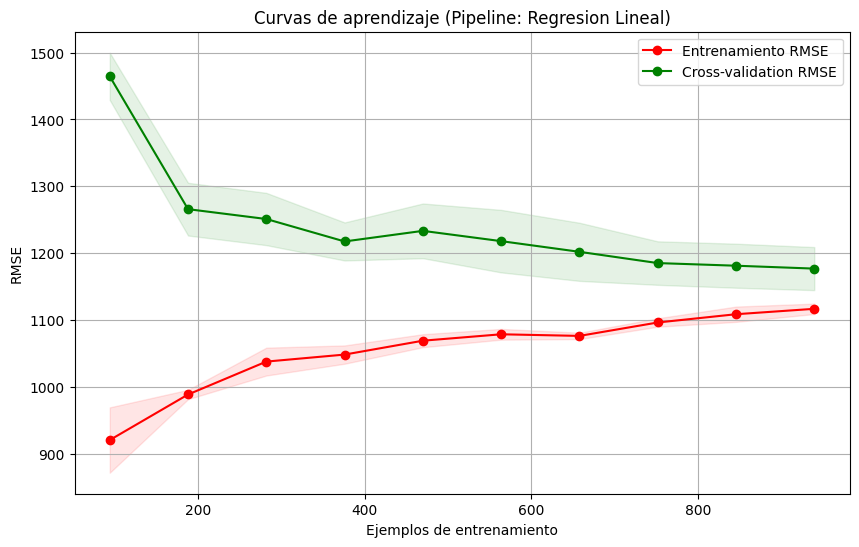

Curvas de aprendizaje generadas correctamente.


In [28]:
# Curvas de aprendizaje usando el pipeline completo sobre datos crudos
# Esto es correcto: el preprocesamiento se aplica dentro de cada fold de CV
train_sizes, train_scores, test_scores = learning_curve(
    pipeline_lineal, X_train, y_reg_train, cv=5,
    scoring="neg_mean_squared_error", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_scores_rmse = np.sqrt(-train_scores)
test_scores_rmse = np.sqrt(-test_scores)

train_scores_mean = np.mean(train_scores_rmse, axis=1)
train_scores_std = np.std(train_scores_rmse, axis=1)
test_scores_mean = np.mean(test_scores_rmse, axis=1)
test_scores_std = np.std(test_scores_rmse, axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, "o-", color="r", label="Entrenamiento RMSE")
plt.plot(train_sizes, test_scores_mean, "o-", color="g", label="Cross-validation RMSE")

plt.title("Curvas de aprendizaje (Pipeline: Regresion Lineal)")
plt.xlabel("Ejemplos de entrenamiento")
plt.ylabel("RMSE")
plt.legend(loc="best")
plt.grid()
plt.show()

print("Curvas de aprendizaje generadas correctamente.")

# **Modelos de Clasificación para Attrition**

Analizar el desbalance de clases en la variable `Attrition`. Se entrenará un modelo de Regresión Logística para predecir `Attrition`. Se reportará la matriz de confusión y la métrica Recall. Además, se explicará el costo de los Falsos Negativos (FN) versus los Falsos Positivos (FP) en el contexto de negocio de fuga de talento.


In [29]:
print("Distribución de clases en y_clf_train (Attrition):")
print(y_clf_train.value_counts())

print("\nProporción de Attrition (Sí):")
print(y_clf_train.value_counts(normalize=True).loc[1])

Distribución de clases en y_clf_train (Attrition):
Attrition_numerical
0    986
1    190
Name: count, dtype: int64

Proporción de Attrition (Sí):
0.16156462585034015


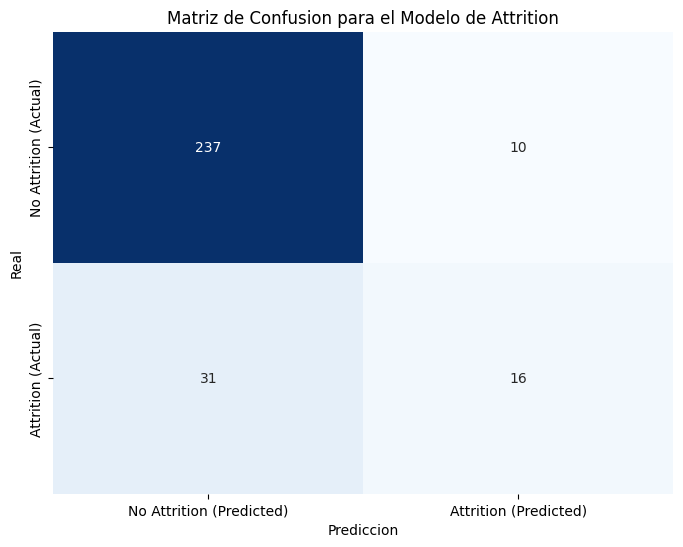


Informe de Clasificacion para el Modelo de Attrition:
              precision    recall  f1-score   support

No Attrition       0.88      0.96      0.92       247
   Attrition       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Se entrena el pipeline de clasificacion sobre datos sin procesar
# El ColumnTransformer se aplica internamente, evitando fuga de informacion
pipeline_clf.fit(X_train, y_clf_train)

# Se extrae el modelo para acceder a coeficientes mas adelante
logistic_reg_model = pipeline_clf.named_steps["model"]

y_pred_clf = pipeline_clf.predict(X_test)

cm = confusion_matrix(y_clf_test, y_pred_clf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Attrition (Predicted)", "Attrition (Predicted)"],
            yticklabels=["No Attrition (Actual)", "Attrition (Actual)"])
plt.title("Matriz de Confusion para el Modelo de Attrition")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.show()

print("\nInforme de Clasificacion para el Modelo de Attrition:")
print(classification_report(y_clf_test, y_pred_clf, target_names=["No Attrition", "Attrition"]))

## **El problema de tener grupos tan desiguales en Attrition**
Al revisar los datos de Attrition en nuestro grupo de entrenamiento (y_clf_train), nos dimos cuenta de que hay una diferencia muy grande entre los grupos:

* Los que NO se fueron (Clase 'No'): 986 personas.

* Los que SÍ se fueron (Clase 'Sí'): 190 personas.

Básicamente, solo el 16% de los empleados se han ido de la empresa. Que los datos estén así de "desparejos" nos trae varios problemas a la hora de armar el modelo:

El "Accuracy" (Exactitud) nos puede mentir: Si el modelo decide decir que "No" a todo el mundo por defecto, tendría un 84% de acierto. Suena bien, pero en realidad no sirve para nada, porque nuestra meta es justamente encontrar a ese pequeño grupo que sí se va a ir.

El modelo se vuelve "flojo": Los modelos suelen irse por el camino fácil y darle prioridad al grupo que tiene más datos. Si no corregimos esto, al modelo le va a costar mucho aprender a identificar a los que renuncian porque tiene muy pocos ejemplos de ellos.

Lo que de verdad importa es el Recall: En este caso, no nos sirve de mucho el acierto general. Lo que realmente nos importa es el Recall (o qué tan buenos somos atrapando a los que sí se van), además del F1-score. Un Recall alto significa que el modelo sí está haciendo su trabajo de avisarnos quiénes tienen riesgo de renunciar.

In [31]:
# El pipeline de clasificacion ya fue entrenado en la celda anterior
# Esta celda confirma que el modelo esta disponible para las siguientes evaluaciones
print("Pipeline de clasificacion disponible:", pipeline_clf)
print("Modelo extraido: logistic_reg_model disponible")

Pipeline de clasificacion disponible: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel',...
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object'))])),
        

In [32]:
# Las predicciones ya se realizaron dentro de pipeline_clf en la celda anterior
# Se confirma que y_pred_clf esta disponible
print("y_pred_clf disponible, shape:", y_pred_clf.shape)

y_pred_clf disponible, shape: (294,)


In [33]:
from sklearn.metrics import confusion_matrix, recall_score

cm = confusion_matrix(y_clf_test, y_pred_clf)
print("Matriz de Confusion:")
print(cm)

recall = recall_score(y_clf_test, y_pred_clf)
print(f"Recall Score: {recall:.4f}")

Matriz de Confusion:
[[237  10]
 [ 31  16]]
Recall Score: 0.3404


In [34]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# Se usan las probabilidades del pipeline directamente sobre datos sin procesar
y_pred_proba_clf = pipeline_clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds_roc = roc_curve(y_clf_test, y_pred_proba_clf)
roc_auc = auc(fpr, tpr)

precision, recall, thresholds_pr = precision_recall_curve(y_clf_test, y_pred_proba_clf)
pr_auc = auc(recall, precision)

print(f"ROC AUC: {roc_auc:.4f}")
print(f"Precision-Recall AUC: {pr_auc:.4f}")

ROC AUC: 0.8128
Precision-Recall AUC: 0.5823


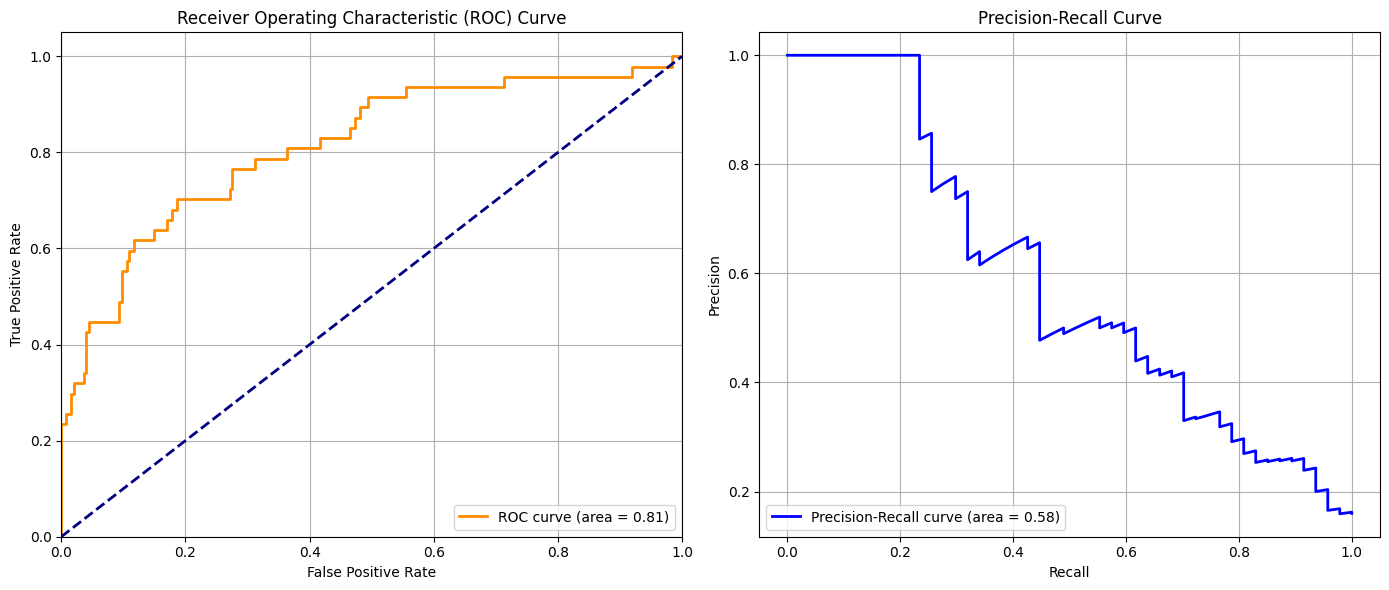

In [35]:
plt.figure(figsize=(14, 6))

# Plot ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.show()

## **Análisis de Costos: Falsos Negativos (FN) vs. Falsos Positivos (FP) en la Predicción de Attrition**

En cualquier proyecto de analítica de datos aplicada a RR.HH., no basta con que el modelo "prediga bien"; hay que entender el impacto económico de los errores de clasificación. En el caso específico de la rotación de personal (Attrition), la matriz de confusión nos revela un trade-off crítico entre Falsos Negativos y Falsos Positivos.


* **1. Falsos Negativos (FN)**
  * Contexto: El modelo etiqueta a un empleado como "estable" (No rotará), pero en la práctica, el empleado termina renunciando.

  * Impacto en el negocio: Este es, por lejos, el escenario más costoso para la organización. Al no detectar el riesgo, la empresa pierde la oportunidad de ejecutar un plan de retención. Los costos derivados son masivos:

  * Fuga de capital intelectual: Pérdida de know-how técnico y experiencia acumulada.

  * Costos de reemplazo: Gastos en procesos de reclutamiento, headhunting y onboarding.

  * Curva de aprendizaje: Caída en la productividad mientras el nuevo integrante se adapta.

  * Efecto dominó: Impacto negativo en la moral del equipo y posibles retrasos en proyectos críticos o pérdida de cuentas clave.

  * Métrica clave: Para mitigar los FN, debemos priorizar un Recall (Sensibilidad) elevado. En ingeniería, preferimos "pecar de precavidos" antes que dejar pasar una renuncia inminente.

* **2. Falsos Positivos (FP)**

  * Contexto: El sistema lanza una alerta de que un empleado se va a ir, pero en realidad el colaborador no tiene intenciones de renunciar.

  * Impacto en el negocio: Aunque no es tan catastrófico como un FN, genera ineficiencias operativas y desperdicio de presupuesto:

  * Burnout de recursos: Inversión innecesaria de tiempo de los managers en entrevistas de retención o mentorías.

  * Costo de oportunidad: Se destinan bonos, ajustes salariales o beneficios a alguien que no los necesitaba para quedarse, descuidando quizás a quienes sí están en riesgo real.

  * Ruido organizacional: Acciones de retención mal enfocadas pueden generar incomodidad o expectativas irreales en el personal.

  * Métrica clave: Si los recursos para retención son limitados, debemos vigilar la Precisión para asegurar que nuestras intervenciones sean quirúrgicas y confiables.

  **Conclusión técnica**
Para este sistema de Attrition, el objetivo principal es optimizar el Recall sin desplomar la Precisión. Un equilibrio sano, reflejado en el F1-Score, nos permitirá salvar el talento valioso sin que el departamento de finanzas nos reclame por el desperdicio de recursos en "falsas alarmas".

## **Costo de Falsos Negativos (FN) vs. Falsos Positivos (FP) en la Predicción de Attrition**

En el contexto de la predicción de rotación de empleados (`Attrition`), entender el impacto de los Falsos Negativos (FN) y Falsos Positivos (FP) es crucial para la toma de decisiones empresariales. El objetivo es minimizar los costos asociados a estos errores.

*   **Falsos Negativos (FN):**
    *   **Definición:** Ocurren cuando el modelo predice que un empleado *no rotará*, pero en realidad el empleado *sí rota*. (El modelo dice 'No', pero la realidad es 'Sí').
    *   **Costo de Negocio:** Este es el error más costoso en el contexto de la fuga de talento. Un Falso Negativo implica que la empresa **no tomó ninguna acción preventiva** para retener a un empleado valioso que finalmente se fue. Los costos asociados incluyen:
        *   **Pérdida de conocimiento institucional y experiencia.**
        *   **Disminución de la productividad** del equipo o departamento.
        *   **Gastos significativos de reclutamiento y selección** para encontrar un reemplazo.
        *   **Costos de capacitación** del nuevo empleado.
        *   **Impacto negativo en la moral** del equipo restante.
        *   **Pérdida de relaciones con clientes** o proyectos críticos.
    *   **Prioridad:** En problemas de rotación de empleados, la minimización de Falsos Negativos suele ser una prioridad alta, lo que justifica la importancia de métricas como el *Recall* (sensibilidad para la clase positiva).

*   **Falsos Positivos (FP):**
    *   **Definición:** Ocurren cuando el modelo predice que un empleado *rotará*, pero en realidad el empleado *no rota*. (El modelo dice 'Sí', pero la realidad es 'No').
    *   **Costo de Negocio:** Un Falso Positivo implica que la empresa **invirtió recursos en acciones de retención** (entrevistas, ofertas de contrapuesta, programas de mentoría, mejoras salariales, etc.) en un empleado que no tenía intenciones de irse. Los costos asociados incluyen:
        *   **Gasto de tiempo y recursos** en iniciativas de retención innecesarias.
        *   Posiblemente **generar expectativas** en el empleado sobre las razones de estas acciones, lo que podría llevar a inquietudes.
        *   **Deterioro de la confianza** si las acciones de retención son percibidas como intrusivas o infundadas.
        *   **Redirección de recursos** que podrían haberse utilizado para retener a empleados en riesgo real.
    *   **Prioridad:** Aunque no tan crítico como un FN, un alto número de FP puede llevar a un uso ineficiente de recursos y una posible fatiga de las estrategias de retención. Por ello, la *Precisión* (precision) también es una métrica importante a considerar, ya que indica qué tan confiables son las predicciones positivas del modelo.

# **Interpretación de Modelos**


In [36]:
print("Extracting and displaying coefficients for Linear Regression Model...")

# Create a DataFrame for Linear Regression coefficients
linear_reg_coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': linear_reg_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Linear Regression Coefficients (Top 10 positive and Top 10 negative):")
display(linear_reg_coef_df.head(10))
display(linear_reg_coef_df.tail(10))


Extracting and displaying coefficients for Linear Regression Model...
Linear Regression Coefficients (Top 10 positive and Top 10 negative):


,Feature,Coefficient
39,JobRole_Manager,3490.231334
41,JobRole_Research Director,3371.381608
7,JobLevel,2974.661594
15,TotalWorkingYears,405.018802
32,EducationField_Other,79.210641
20,YearsSinceLastPromotion,75.847193
11,PercentSalaryHike,66.958728
24,BusinessTravel_Travel_Rarely,62.549857
45,MaritalStatus_Divorced,50.397837
25,Department_Human Resources,46.546631


,Feature,Coefficient
6,JobInvolvement,-75.902301
31,EducationField_Medical,-84.039791
21,YearsWithCurrManager,-127.437057
43,JobRole_Sales Executive,-617.891614
36,JobRole_Healthcare Representative,-672.247005
40,JobRole_Manufacturing Director,-740.056283
37,JobRole_Human Resources,-1025.051633
42,JobRole_Research Scientist,-1220.151639
44,JobRole_Sales Representative,-1279.199399
38,JobRole_Laboratory Technician,-1307.015370


In [37]:
print("Extracting and displaying coefficients for Ridge Regression Model...")

# Create a DataFrame for Ridge Regression coefficients
ridge_reg_coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': ridge_reg_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Ridge Regression Coefficients (Top 10 positive and Top 10 negative):")
display(ridge_reg_coef_df.head(10))
display(ridge_reg_coef_df.tail(10))

Extracting and displaying coefficients for Ridge Regression Model...
Ridge Regression Coefficients (Top 10 positive and Top 10 negative):


,Feature,Coefficient
39,JobRole_Manager,3375.529018
41,JobRole_Research Director,3233.678610
7,JobLevel,3013.691969
15,TotalWorkingYears,408.299565
26,Department_Research & Development,84.923757
20,YearsSinceLastPromotion,73.690322
32,EducationField_Other,72.693745
11,PercentSalaryHike,66.381407
24,BusinessTravel_Travel_Rarely,63.916555
45,MaritalStatus_Divorced,51.043460


,Feature,Coefficient
14,StockOptionLevel,-73.925485
31,EducationField_Medical,-82.517883
21,YearsWithCurrManager,-128.244428
43,JobRole_Sales Executive,-597.192504
36,JobRole_Healthcare Representative,-696.662825
40,JobRole_Manufacturing Director,-763.203046
37,JobRole_Human Resources,-874.257260
44,JobRole_Sales Representative,-1192.647920
42,JobRole_Research Scientist,-1199.225486
38,JobRole_Laboratory Technician,-1286.018587


In [38]:
print("Extracting and displaying coefficients for Lasso Regression Model...")

# Create a DataFrame for Lasso Regression coefficients
lasso_reg_coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lasso_reg_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("Lasso Regression Coefficients (Top 10 positive and Top 10 negative):")
display(lasso_reg_coef_df.head(10))
display(lasso_reg_coef_df.tail(10))

Extracting and displaying coefficients for Lasso Regression Model...
Lasso Regression Coefficients (Top 10 positive and Top 10 negative):


,Feature,Coefficient
39,JobRole_Manager,4223.214361
41,JobRole_Research Director,4106.034693
7,JobLevel,2977.701266
15,TotalWorkingYears,404.419063
43,JobRole_Sales Executive,115.152703
32,EducationField_Other,82.545364
20,YearsSinceLastPromotion,75.677286
36,JobRole_Healthcare Representative,66.899963
11,PercentSalaryHike,66.303414
24,BusinessTravel_Travel_Rarely,52.566675


,Feature,Coefficient
6,JobInvolvement,-75.627177
31,EducationField_Medical,-78.204499
22,BusinessTravel_Non-Travel,-81.652299
34,Gender_Female,-85.620543
27,Department_Sales,-94.864467
21,YearsWithCurrManager,-126.938497
37,JobRole_Human Resources,-263.134516
42,JobRole_Research Scientist,-476.254295
44,JobRole_Sales Representative,-540.096139
38,JobRole_Laboratory Technician,-563.250381


In [39]:
print("Extracting and displaying coefficients for Logistic Regression Model...")

# Create a DataFrame for Logistic Regression coefficients
logistic_reg_coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': logistic_reg_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)


display(logistic_reg_coef_df.head(10))
display(logistic_reg_coef_df.tail(10))

Extracting and displaying coefficients for Logistic Regression Model...


,Feature,Coefficient
38,JobRole_Laboratory Technician,1.009173
44,JobRole_Sales Representative,0.810437
23,BusinessTravel_Travel_Frequently,0.672241
49,OverTime_Yes,0.593669
20,YearsSinceLastPromotion,0.531140
28,EducationField_Human Resources,0.510714
10,NumCompaniesWorked,0.480864
2,DistanceFromHome,0.382296
33,EducationField_Technical Degree,0.297112
47,MaritalStatus_Single,0.266748


,Feature,Coefficient
4,EnvironmentSatisfaction,-0.470613
34,Gender_Female,-0.483947
45,MaritalStatus_Divorced,-0.511668
15,TotalWorkingYears,-0.536375
26,Department_Research & Development,-0.580568
36,JobRole_Healthcare Representative,-0.603817
32,EducationField_Other,-0.817034
22,BusinessTravel_Non-Travel,-1.105003
41,JobRole_Research Director,-1.120031
48,OverTime_No,-1.248131


# **Insights y Estrategias Basadas en la Interpretación de los Modelos**

Después de correr los modelos de Regresión (para el ingreso mensual) y Clasificación (para la rotación), sacamos varias conclusiones interesantes analizando los coeficientes. Básicamente, estos números nos dicen qué variables "mueven la aguja" en la empresa.

  * **1. ¿Qué define el sueldo en la organización? (MonthlyIncome)**

    * Al comparar Regresión Lineal, Ridge y Lasso, vimos que los resultados son súper consistentes. No hay sorpresas: el salario está amarrado a la jerarquía y la experiencia.

    * Lo que más suma: Obviamente, tener cargos de Manager o Director de Investigación dispara el sueldo. El JobLevel y los años de experiencia total también son determinantes. Es una estructura de compensación tradicional basada en seniority.

    * Lo que "castiga" el ingreso: Roles como Técnico de Laboratorio o Representante de Ventas están en la parte baja de la tabla. Un dato curioso es que llevar mucho tiempo con el mismo jefe (YearsWithCurrManager) tiene un impacto negativo ligero; esto me suena a que hay gente que se queda "estancada" y no se mueve internamente para buscar mejores sueldos.

  * ¿Qué hacer? La empresa debería ser más transparente con las escalas salariales y armar planes de carrera para que los técnicos no sientan que llegaron a un tope muy rápido.

  * **2. ¿Por qué se está yendo la gente? (Predicción de Attrition)**

    * Aquí usamos Regresión Logística para ver qué aumenta o baja la probabilidad de que alguien renuncie.

    * Fugas de talento (Coeficientes Positivos): * Exceso de chamba: El factor número uno es el OverTime (horas extra). Si la gente se queda después de hora, la probabilidad de que se larguen sube un montón. Lo mismo pasa con los viajes frecuentes.

      * Falta de crecimiento: Los que llevan mil años sin un ascenso (YearsSinceLastPromotion) son candidatos fijos para irse.

      * Roles críticos: Los Técnicos de Laboratorio y de Ventas tienen la tasa de rotación más alta. Puede ser por el estrés o porque el sueldo no les compensa el esfuerzo.

    * Retención (Coeficientes Negativos):

    * Calidad de vida: No trabajar horas extra y no viajar es lo que más retiene a la gente.

    * Ambiente: Si el empleado está contento con el entorno físico y el clima laboral (EnvironmentSatisfaction), es mucho más difícil que se vaya.

    * Seniority: Los empleados con más años de carrera total suelen ser más estables.

**Acciones concretas para el negocio:**
Bajarle a las horas extra: Hay que revisar la carga laboral. El burnout nos está matando el KPI de retención.

Mover el escalafón: No podemos tener a gente talentosa estancada por años en el mismo puesto. Hay que agilizar las promociones.

Foco en técnicos y ventas: Estos departamentos son "zonas rojas". Necesitan un plan de incentivos o mentorías antes de que el costo de reemplazo se nos vaya a las nubes.

# **Conclusiones y Recomendaciones**


## **Hallazgos Clave de la Exploración y Calidad del Dato**

1.  **Ausencia de Valores Nulos:** Se confirmó que el dataset no presenta valores nulos en ninguna de sus columnas, lo que simplifica la fase de preprocesamiento al no requerir estrategias de imputación.

2.  **Identificación de Columnas Irrelevantes:**
    *   `EmployeeCount` y `StandardHours` fueron identificadas como columnas constantes (tienen un único valor para todas las filas), por lo que no aportan variabilidad y son irrelevantes para el modelado.
    *   `Over18` también resultó ser una columna constante ('Y' para todas las filas), careciendo de valor predictivo.
    *   `EmployeeNumber` se identificó como un identificador único, útil para la gestión de datos pero no predictivo para el modelo. Todas estas columnas fueron correctamente eliminadas.

3.  **Desbalance de Clases en 'Attrition':** La variable objetivo de clasificación, `Attrition`, presenta un marcado desbalance de clases. Aproximadamente el 16% de los empleados han rotado ('Yes'), mientras que el 84% no lo han hecho ('No'). Este desbalance es crucial para la evaluación del modelo de clasificación, donde métricas como el *Recall* para la clase positiva son más relevantes que la exactitud general.

4.  **Correlaciones y Distribuciones Relevantes:**
    *   **MonthlyIncome:** Se observaron fuertes correlaciones positivas entre `MonthlyIncome` y variables como `JobLevel` y `TotalWorkingYears`, lo cual es intuitivo y esperado. Esto sugiere que el nivel de puesto y la experiencia general son los principales impulsores del salario.
    *   **Attrition:** El análisis de distribución para las variables categóricas reveló que algunas, como `JobRole`, `Department`, `MaritalStatus` y `OverTime`, tienen distribuciones diferentes para los grupos que rotan y los que no, indicando su potencial predictivo para `Attrition`.
    *   **Outliers:** Se identificaron posibles *outliers* en varias variables numéricas, como `MonthlyIncome`, `TotalWorkingYears` y `YearsAtCompany`, lo cual es común en datos reales y fue manejado implícitamente por los modelos de regresión lineal (que son robustos a outliers, aunque podrían verse afectados si son muy extremos) y por la normalización aplicada en el preprocesamiento.

## **Hallazgos Clave de los Modelos de Regresión para MonthlyIncome**

1.  **Rendimiento del Modelo:**
    *   **Métricas de Evaluación:** Los tres modelos de regresión (Lineal, Ridge y Lasso) mostraron un rendimiento muy similar y excelente en la predicción de `MonthlyIncome`.
        *   **Linear Regression:** R-squared: 0.9541, RMSE: 1053.05
        *   **Ridge Regression:** R-squared: 0.9541, RMSE: 1052.80
        *   **Lasso Regression:** R-squared: 0.9541, RMSE: 1052.68
    *   **Interpretación:** Un R-squared cercano a 0.95 indica que los modelos pueden explicar aproximadamente el 95% de la varianza en `MonthlyIncome`. El RMSE, alrededor de 1053, representa el error promedio en las predicciones salariales, lo cual es relativamente bajo considerando el rango de salarios. La similitud en las métricas sugiere que la regularización (Ridge y Lasso) no aportó una mejora sustancial en el rendimiento predictivo en este caso, posiblemente porque el modelo lineal ya era robusto o porque no hay una multicolinealidad severa que los métodos de regularización deban abordar en gran medida.

2.  **Coeficientes Más Importantes (Predictoras de MonthlyIncome):**
    *   Los coeficientes de los tres modelos de regresión fueron muy consistentes entre sí, destacando las mismas variables como las más influyentes.
    *   **Impacto Positivo:** Las variables con mayor coeficiente positivo y, por lo tanto, con mayor impacto en el aumento del `MonthlyIncome` fueron:
        *   `JobRole_Manager` y `JobRole_Research Director`: Ser Gerente o Director de Investigación tiene el impacto más significativo en el ingreso mensual, lo cual es totalmente esperado.
        *   `JobLevel`: A mayor nivel de puesto (JobLevel), mayor ingreso. Esta es la variable numérica más potente y está fuertemente relacionada con los roles mencionados.
        *   `TotalWorkingYears`: Más años de experiencia laboral se asocian con ingresos mensuales más altos.
        *   `YearsSinceLastPromotion`: Un mayor tiempo desde la última promoción puede indicar un mayor nivel de carrera, aunque también puede ser un indicador de estancamiento si no se acompaña de otros factores.
    *   **Impacto Negativo:** Algunas variables tuvieron un impacto negativo, aunque con coeficientes de menor magnitud en comparación con las positivas clave:
        *   `JobRole_Sales Representative` y `JobRole_Laboratory Technician`: Estos roles, en comparación con otros roles base (al ser one-hot encoded, se interpretan respecto a la categoría base omitida o al promedio), tienden a tener un ingreso mensual más bajo.
        *   `Department_Sales`: Estar en el departamento de ventas puede tener un impacto ligeramente negativo o una menor contribución al ingreso mensual en comparación con otros departamentos, después de controlar por otros factores como el `JobRole`.
    *   **Conclusión:** La estructura salarial está fuertemente ligada al `JobLevel`, a la experiencia (`TotalWorkingYears`) y a roles de alta gerencia o dirección. Los modelos validan que estas son las principales palancas del ingreso mensual.

## **Hallazgos Clave del Modelo de Clasificación para Attrition**

1.  **Desbalance de Clases:** Se confirmó un marcado desbalance en la variable `Attrition` en el conjunto de entrenamiento (aproximadamente 16% 'Sí', 84% 'No'). Esto implica que la `accuracy` (exactitud) no es una métrica adecuada para evaluar el rendimiento del modelo, y se debe priorizar el `Recall` para la clase positiva.

2.  **Rendimiento del Modelo de Regresión Logística:**
    *   **Matriz de Confusión:**
        ```
        [[237  10]
         [ 31  16]]
        ```
        *   **Verdaderos Negativos (TN = 237):** Empleados que el modelo predijo correctamente que NO rotarían y NO rotaron.
        *   **Falsos Positivos (FP = 10):** Empleados que el modelo predijo que SÍ rotarían, pero NO rotaron.
        *   **Falsos Negativos (FN = 31):** Empleados que el modelo predijo que NO rotarían, pero SÍ rotaron.
        *   **Verdaderos Positivos (TP = 16):** Empleados que el modelo predijo correctamente que SÍ rotarían y SÍ rotaron.
    *   **Recall Score:** 0.3404 (para la clase 'Sí' o rotación).

3.  **Interpretación del Recall y Desbalance:** Un `Recall` de 0.3404 significa que el modelo solo fue capaz de identificar correctamente al 34% de los empleados que realmente rotaron. Esto es un resultado bajo y sugiere que el modelo tiene dificultades para capturar la clase minoritaria, lo cual es una consecuencia directa del desbalance de clases. Para un problema crítico como la retención de talento, este `Recall` es insuficiente y necesita mejoras.

4.  **Costo de Falsos Negativos (FN) vs. Falsos Positivos (FP):**
    *   **Falsos Negativos (31 instancias):** Un FN ocurre cuando el modelo predice erróneamente que un empleado no rotará, pero sí lo hace. En el contexto de negocio, estos son los errores más costosos. Significa que la empresa pierde 31 empleados que podrían haberse retenido si el modelo los hubiera identificado a tiempo. Los costos asociados incluyen pérdida de conocimiento, gastos de contratación y capacitación, y disminución de productividad. Dada la prioridad de retención, minimizar los FN es crucial.
    *   **Falsos Positivos (10 instancias):** Un FP ocurre cuando el modelo predice erróneamente que un empleado rotará, pero no lo hace. Estos 10 casos implican que la empresa podría haber invertido recursos en acciones de retención innecesarias para empleados que no tenían intención de irse. Si bien esto genera un costo de recursos, generalmente es menos perjudicial que la pérdida de talento (FN). Sin embargo, un alto número de FP podría llevar a la ineficiencia y a la fatiga de las estrategias de retención.

5.  **Coeficientes Más Importantes (Predictoras de Attrition):**
    *   **Impacto Positivo (aumentan la probabilidad de rotación):**
        *   `JobRole_Laboratory Technician` y `JobRole_Sales Representative`: Estar en estos roles aumenta significativamente la probabilidad de rotación.
        *   `BusinessTravel_Travel_Frequently`: Viajar frecuentemente se asocia con una mayor probabilidad de rotación.
        *   `OverTime_Yes`: Trabajar horas extras es un fuerte predictor de rotación.
        *   `YearsSinceLastPromotion` y `NumCompaniesWorked`: Un mayor tiempo desde la última promoción y haber trabajado en más empresas se asocian con mayor rotación.
    *   **Impacto Negativo (disminuyen la probabilidad de rotación):**
        *   `JobLevel` y `MonthlyIncome` (aunque `MonthlyIncome` no fue usado como feature, se entiende que `JobLevel` es un proxy muy cercano): Un `JobLevel` más alto reduce la probabilidad de rotación, lo cual está alineado con la retención del talento más valioso.
        *   `TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`: La antigüedad en la empresa, en el rol actual y con el gerente actual, así como la experiencia laboral total, son factores que reducen la probabilidad de rotación. Esto sugiere que los empleados más estables y experimentados son menos propensos a irse.
        *   `JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction`, `WorkLifeBalance`: Una mayor satisfacción en estos aspectos laborales reduce la probabilidad de rotación.


## **Recomendaciones Accionables para el Negocio**

Basado en el análisis de los coeficientes de los modelos de regresión y clasificación, se pueden derivar las siguientes recomendaciones estratégicas y operativas:

#### A. Para la Optimización de la Estructura Salarial (Basado en el modelo de `MonthlyIncome`):

1.  **Reforzar la Progresión Salarial Ligada al Nivel de Puesto y Experiencia:** Dado que `JobLevel` y `TotalWorkingYears` son los predictores más fuertes de `MonthlyIncome`, la empresa debe asegurarse de tener rutas de carrera claras y estructuras salariales transparentes que recompensen la experiencia y el avance de nivel.
    *   **Acción:** Revisar y comunicar abiertamente las bandas salariales asociadas a cada `JobLevel` y considerar ajustar los incrementos salariales con la antigüedad (`TotalWorkingYears`) para mantener la competitividad y la motivación.

2.  **Evaluar Roles de Baja Remuneración:** Los roles como `Sales Representative` y `Laboratory Technician` muestran coeficientes negativos significativos, lo que indica que tienen ingresos mensuales consistentemente más bajos en comparación con otros roles. Esto es coherente con su mayor probabilidad de rotación.
    *   **Acción:** Realizar un análisis de mercado para estos roles y evaluar si sus salarios base son competitivos. Considerar programas de incentivos o bonificaciones específicos para estos puestos para mejorar la satisfacción y reducir la rotación.

3.  **Incentivar la Permanencia en Roles Estratégicos:** Los roles de `Manager` y `Research Director` son los mejor remunerados, lo que sugiere que la empresa valora y recompensa estos puestos clave.
    *   **Acción:** Continuar invirtiendo en el desarrollo de líderes y directores, asegurando que sus paquetes de compensación sigan siendo atractivos para retener el talento de alto nivel.

#### B. Para la Estrategia de Retención de Empleados (Basado en el modelo de `Attrition`):

1.  **Intervenir Proactivamente en Roles de Alto Riesgo:** Los `Laboratory Technician` y `Sales Representative` tienen una probabilidad de rotación significativamente alta.
    *   **Acción:** Implementar programas de retención dirigidos específicamente a estos grupos. Esto podría incluir oportunidades de desarrollo profesional, programas de mentoría, revisiones salariales personalizadas y mejora de las condiciones de trabajo.

2.  **Gestionar el Estrés por Viajes y Horas Extras:** `BusinessTravel_Travel_Frequently` y `OverTime_Yes` son fuertes predictores de rotación.
    *   **Acción:** Monitorear de cerca los patrones de viaje y las horas extras. Ofrecer flexibilidad, compensación adicional por tiempo extra o beneficios de bienestar para empleados que viajan mucho o trabajan muchas horas. Fomentar un equilibrio saludable entre vida laboral y personal.

3.  **Fomentar la Satisfacción Laboral y el Equilibrio Vida-Trabajo:** `JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction` y `WorkLifeBalance` tienen un impacto negativo en la rotación (es decir, una mayor satisfacción reduce la rotación).
    *   **Acción:** Realizar encuestas de satisfacción laboral regularmente para identificar áreas de mejora. Implementar iniciativas para mejorar el ambiente de trabajo, las relaciones con los compañeros/supervisores y ofrecer opciones de conciliación (horarios flexibles, teletrabajo, etc.).

4.  **Revisar Políticas de Promoción y Antigüedad:** `YearsSinceLastPromotion` y `NumCompaniesWorked` influyen en la rotación. Un mayor tiempo sin promoción aumenta la rotación, y haber trabajado en más empresas puede indicar una menor lealtad.
    *   **Acción:** Establecer planes de desarrollo de carrera claros y oportunidades de promoción regulares. Para empleados con menos antigüedad o que han trabajado en muchas empresas, ofrecer programas de onboarding mejorados o incentivos a largo plazo para fomentar la lealtad.

5.  **Apalancar la Antigüedad:** Empleados con más años en la empresa, en su rol actual y con su gerente actual son menos propensos a rotar.
    *   **Acción:** Reconocer y valorar la antigüedad. Crear programas de reconocimiento para empleados de larga trayectoria y utilizar su experiencia para mentorizar a nuevos empleados, reforzando su sentido de pertenencia.

#### C. Consideraciones Generales:

*   **Monitoreo Continuo:** Implementar un sistema de monitoreo continuo de los indicadores clave de riesgo de rotación y de las tendencias salariales para adaptar las estrategias a tiempo.
*   **Cultura Organizacional:** Más allá de las métricas, la cultura organizacional, el liderazgo y la comunicación transparente son fundamentales para la retención y la satisfacción.

## **Riesgos Potenciales y Limitaciones de los Modelos**

Es fundamental reconocer que la implementación de cualquier modelo predictivo en un entorno real conlleva riesgos y limitaciones que deben ser gestionados:

1.  **Dependencia de la Calidad del Dato y Relevancia Futura:**
    *   **Riesgo:** Los modelos se entrenaron con datos históricos. Si la calidad de los datos futuros disminuye (errores de registro, datos incompletos) o si los factores que influyen en el `MonthlyIncome` o `Attrition` cambian significativamente con el tiempo (por ejemplo, nuevas políticas de compensación, cambios culturales, cambios en el mercado laboral), la precisión y relevancia de los modelos pueden degradarse. La ausencia de valores nulos y la limpieza inicial son fortalezas, pero no garantizan la calidad futura.
    *   **Implicación:** Los modelos requerirán un monitoreo continuo y un reentrenamiento periódico para asegurar su validez.

2.  **Causalidad vs. Correlación:**
    *   **Riesgo:** Aunque los modelos identifican fuertes correlaciones y variables influyentes, no establecen causalidad de manera inherente. Por ejemplo, `JobLevel` y `TotalWorkingYears` están fuertemente correlacionados con `MonthlyIncome`, lo cual es intuitivo. Sin embargo, en `Attrition`, si `OverTime_Yes` es un predictor fuerte de rotación, la empresa debe investigar si el tiempo extra es la *causa* de la insatisfacción o si es un *síntoma* de otras condiciones laborales subyacentes.
    *   **Implicación:** Las recomendaciones accionables deben ser vistas como hipótesis a investigar y no como soluciones garantizadas sin una comprensión más profunda de los mecanismos causales.

3.  **Representatividad de la Muestra:**
    *   **Riesgo:** El análisis se basó en un único dataset de una empresa específica. Las características de los empleados, la cultura organizacional, las políticas salariales y los factores de retención podrían no ser generalizables a otras empresas o incluso a diferentes departamentos dentro de la misma organización si estos tienen dinámicas muy distintas.
    *   **Implicación:** La aplicación de estos modelos a otros contextos debe hacerse con cautela y, idealmente, con una validación adicional sobre datos específicos de ese nuevo contexto.

4.  **Desbalance de Clases en Attrition y Sesgo del Modelo:**
    *   **Riesgo:** A pesar de haber estratificado la división de datos, el modelo de clasificación para `Attrition` sigue mostrando un bajo `Recall` para la clase minoritaria ('Sí'). Esto significa que muchos empleados en riesgo real de rotación no son identificados. Si bien se explicó el costo de los FN, el riesgo es que las acciones de retención se dirijan solo a una fracción de los empleados que realmente las necesitan.
    *   **Implicación:** Se necesitan técnicas adicionales para manejar el desbalance de clases (como *oversampling*, *undersampling*, o algoritmos más avanzados como XGBoost con ponderación de clases) para mejorar la detección de la rotación.

5.  **Impacto de Acciones de Retención:**
    *   **Riesgo:** Las recomendaciones de negocio buscan mitigar la rotación. Sin embargo, la implementación de estas acciones (e.g., programas de bienestar, ajustes salariales) puede influir en la percepción de los empleados y en los datos futuros, cambiando los patrones que el modelo aprendió inicialmente. Podría generar expectativas no deseadas o cambiar las dinámicas laborales.
    *   **Implicación:** Es crucial medir el impacto de las intervenciones y evaluar si las acciones tomadas tienen el efecto deseado, ajustando la estrategia y los modelos seg\u00fan sea necesario.

6.  **Errores en las Predicciones:**
    *   **Riesgo:** Los modelos, aunque precisos, no son perfectos. Tanto los errores de predicción de `MonthlyIncome` (RMSE ~1053) como los FN y FP en `Attrition` implican que habrá decisiones de negocio basadas en información imperfecta. Por ejemplo, una predicción errónea del salario podría llevar a ofertas no competitivas, y un FN en `Attrition` a la pérdida inesperada de un empleado.

## **Supuestos Importantes Considerados Durante el Estudio**

Para llevar a cabo este análisis y derivar las conclusiones y recomendaciones, se han considerado los siguientes supuestos:

1.  **Representatividad del Dataset:** Se asume que el conjunto de datos proporcionado es una muestra representativa de la población de empleados de la empresa en cuestión. Esto implica que los patrones y relaciones observados en este dataset son válidos y generalizables para la fuerza laboral de la organización.

2.  **Estabilidad de los Patrones Subyacentes:** Se asume que las relaciones entre las características de los empleados y las variables objetivo (`MonthlyIncome` y `Attrition`) son relativamente estables a lo largo del tiempo. Es decir, los factores que influyeron en el ingreso mensual y la rotación en el período cubierto por los datos continuarán siendo relevantes en el futuro cercano, a menos que existan cambios organizacionales o de mercado significativos.

3.  **No Existencia de Fuga de Información Crítica no Identificada:** Se asume que el proceso de identificación de fuga de información fue exhaustivo y que no existen otras variables en el dataset que, de manera sutil o indirecta, incorporen información del futuro o de la variable objetivo de forma no legítima en un escenario de predicción real.

4.  **Costo Asimétrico de Errores para Attrition:** Para el modelo de clasificación de `Attrition`, se asume que el costo de un Falso Negativo (FN - no predecir rotación cuando sí ocurre) es significativamente mayor que el costo de un Falso Positivo (FP - predecir rotación cuando no ocurre). Esta asunción justifica la priorización de la métrica *Recall* para la clase positiva en la evaluación del modelo.

5.  **Interpretabilidad de Coeficientes Lineales:** Se asume que la interpretación directa de los coeficientes de los modelos lineales (Regresión Lineal, Ridge, Lasso, y Regresión Logística) proporciona una comprensión significativa de la importancia y la dirección del impacto de las características en las variables objetivo. Esto es una simplificación, ya que las relaciones en el mundo real pueden ser más complejas y no necesariamente lineales.

6.  **Disponibilidad de Características en Tiempo Real:** Se asume que todas las características utilizadas en los modelos estarán disponibles en el momento en que se necesite hacer una predicción en un entorno de producción (por ejemplo, al contratar un nuevo empleado o al evaluar el riesgo de rotación de un empleado existente).


## **Supuestos Importantes Considerados Durante el Estudio**

Para llevar a cabo este análisis y derivar las conclusiones y recomendaciones, se han considerado los siguientes supuestos:

1.  **Representatividad del Dataset:** Se asume que el conjunto de datos proporcionado es una muestra representativa de la población de empleados de la empresa en cuestión. Esto implica que los patrones y relaciones observados en este dataset son válidos y generalizables para la fuerza laboral de la organización.

2.  **Estabilidad de los Patrones Subyacentes:** Se asume que las relaciones entre las características de los empleados y las variables objetivo (`MonthlyIncome` y `Attrition`) son relativamente estables a lo largo del tiempo. Es decir, los factores que influyeron en el ingreso mensual y la rotación en el período cubierto por los datos continuarán siendo relevantes en el futuro cercano, a menos que existan cambios organizacionales o de mercado significativos.

3.  **No Existencia de Fuga de Información Crítica no Identificada:** Se asume que el proceso de identificación de fuga de información fue exhaustivo y que no existen otras variables en el dataset que, de manera sutil o indirecta, incorporen información del futuro o de la variable objetivo de forma no legítima en un escenario de predicción real.

4.  **Costo Asimétrico de Errores para Attrition:** Para el modelo de clasificación de `Attrition`, se asume que el costo de un Falso Negativo (FN - no predecir rotación cuando sí ocurre) es significativamente mayor que el costo de un Falso Positivo (FP - predecir rotación cuando no ocurre). Esta asunción justifica la priorización de la métrica *Recall* para la clase positiva en la evaluación del modelo.

5.  **Interpretabilidad de Coeficientes Lineales:** Se asume que la interpretación directa de los coeficientes de los modelos lineales (Regresión Lineal, Ridge, Lasso, y Regresión Logística) proporciona una comprensión significativa de la importancia y la dirección del impacto de las características en las variables objetivo. Esto es una simplificación, ya que las relaciones en el mundo real pueden ser más complejas y no necesariamente lineales.

6.  **Disponibilidad de Características en Tiempo Real:** Se asume que todas las características utilizadas en los modelos estarán disponibles en el momento en que se necesite hacer una predicción en un entorno de producción (por ejemplo, al contratar un nuevo empleado o al evaluar el riesgo de rotación de un empleado existente).
